In [47]:
%run twisted_graphene.py
from ipywidgets import interact_manual

In [48]:
import warnings
warnings.filterwarnings("ignore")

In [64]:
a=2.46
s3=np.sqrt(3)
a1=a*np.array([s3/2,-1/2,0.0])
a2=a*np.array([s3/2,1/2,0.0])

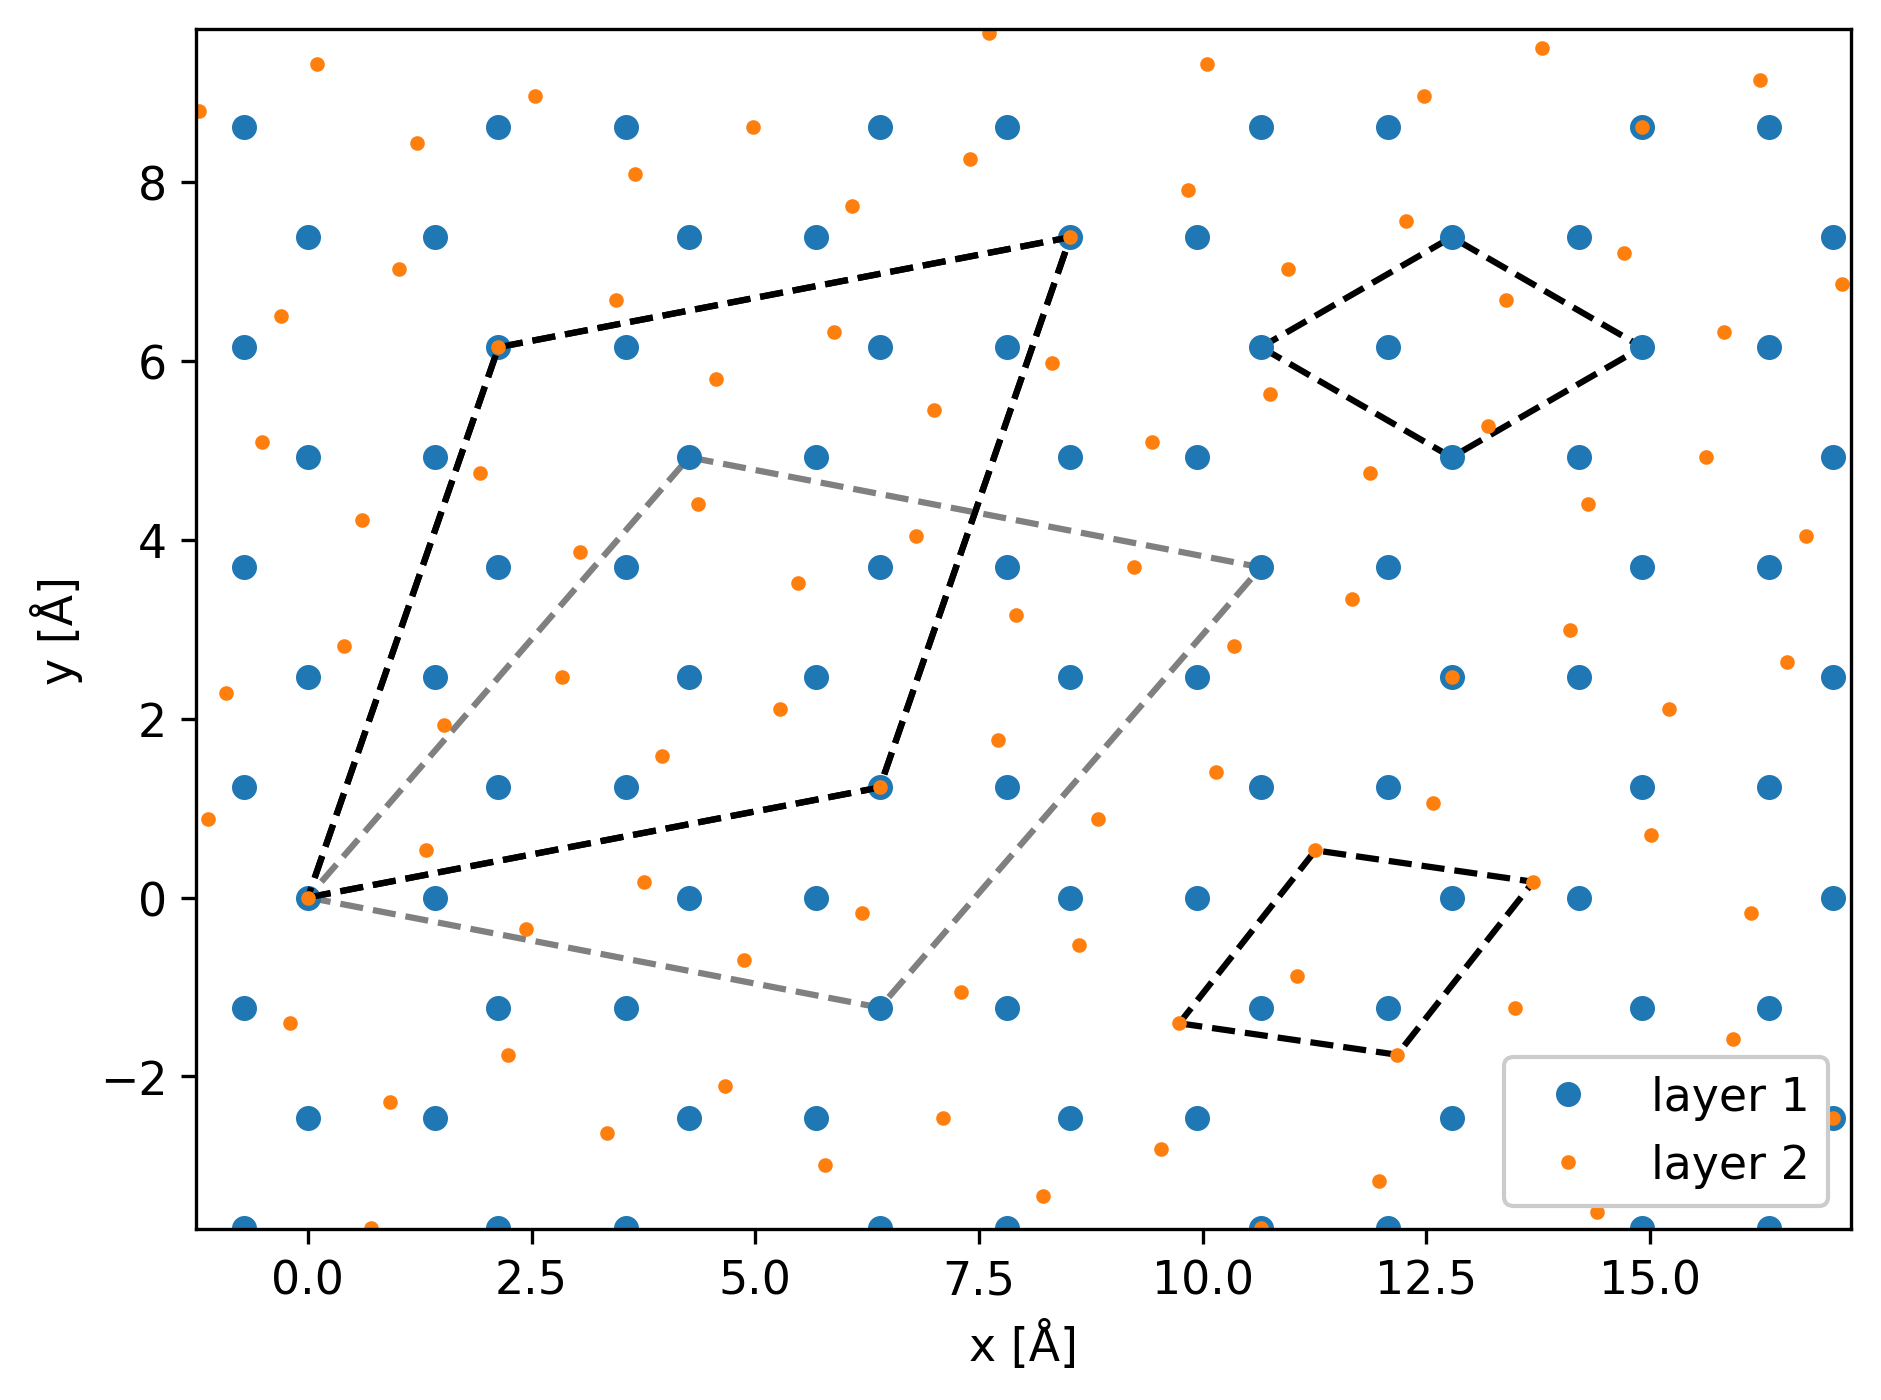

In [328]:
p,q=1,1
r,L1,L2=superlattice(p,q)
N=number_of_sublattice_positions(p,q)
vertices=np.array([[0,0,0],L1,L1+L2,L2,[0,0,0]])
rotated_vertices=vertices@rot(-twist_angle(p,q)).T

m1,n1=0,5
layer1_vertices=np.array([[0,0,0],a1,a1+a2,a2,[0,0,0]])+m1*a1+n1*a2

m2,n2=4,0
a1t=rot(twist_angle(p,q))@a1
a2t=rot(twist_angle(p,q))@a2
layer2_vertices=np.array([[0,0,0],a1t,a1t+a2t,a2t,[0,0,0]])+m2*a1t+n2*a2t

plt.plot(vertices[:,0],vertices[:,1],'k--')
plt.plot(rotated_vertices[:,0],rotated_vertices[:,1],'--',color='gray')
plt.plot(layer1_vertices[:,0],layer1_vertices[:,1],'k--')
plt.plot(layer2_vertices[:,0],layer2_vertices[:,1],'k--')

unit_cell_index_max=3

for m in range(-unit_cell_index_max,unit_cell_index_max+1):
    for n in range(-unit_cell_index_max,unit_cell_index_max+1):
        translation=m*L1+n*L2
        rr=r+translation
        plt.plot(rr[0:N,0],rr[0:N,1],'.',ms=10,color='tab:blue')
        plt.plot(rr[N:2*N,0],rr[N:2*N,1],'.',ms=10,color='tab:blue')

plt.plot(vertices[:,0],vertices[:,1],'k--')
for m in range(-unit_cell_index_max,unit_cell_index_max+1):
    for n in range(-unit_cell_index_max,unit_cell_index_max+1):
        translation=m*L1+n*L2
        rr=r+translation
        plt.plot(rr[2*N:3*N,0],rr[2*N:3*N,1],'.',ms=5,color='tab:orange')
        plt.plot(rr[3*N::,0],rr[3*N::,1],'.',ms=5,color='tab:orange')
        
plt.legend(['__nolegend__']*4+['layer 1']+['__nolegend__']*100+['layer 2'],framealpha=1)
plt.axis('equal')
plt.xlabel('x [Å]')
plt.ylabel('y [Å]')
plt.xlim((-1.0,18-1.0))
plt.ylim((-1.0,8-1.0))
plt.tight_layout()
plt.savefig('tbg_unit_cell_schematic.png',dpi=300)
plt.show()

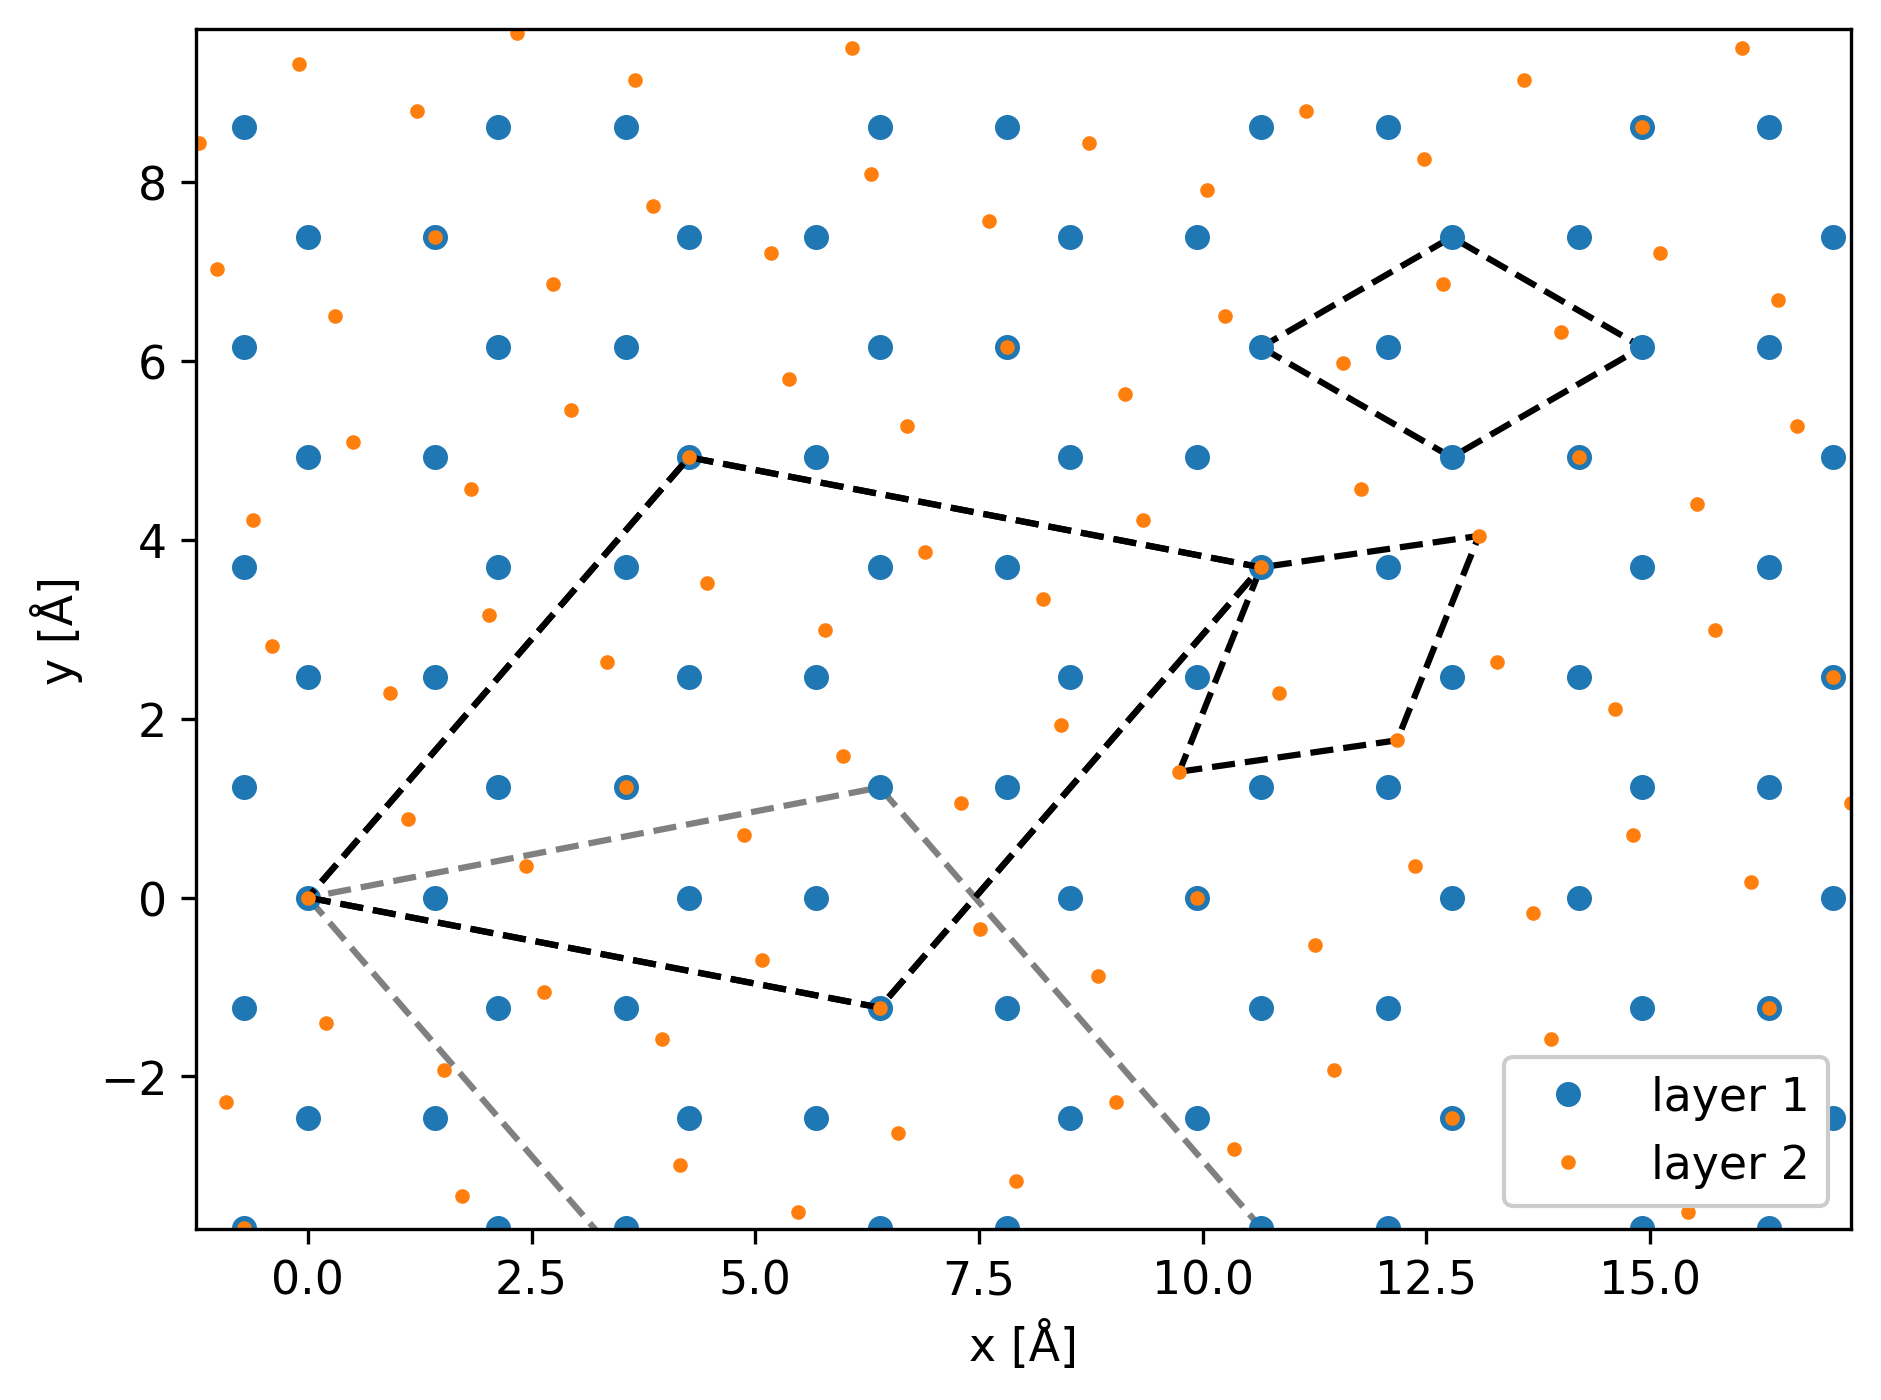

In [329]:
p,q=1,3
r,L1,L2=superlattice(p,q)
N=number_of_sublattice_positions(p,q)
vertices=np.array([[0,0,0],L1,L1+L2,L2,[0,0,0]])
rotated_vertices=vertices@rot(-twist_angle(p,q)).T

m1,n1=0,5
layer1_vertices=np.array([[0,0,0],a1,a1+a2,a2,[0,0,0]])+m1*a1+n1*a2

m2,n2=4,0
a1t=rot(twist_angle(p,q))@a1
a2t=rot(twist_angle(p,q))@a2
layer2_vertices=np.array([[0,0,0],a1t,a1t+a2t,a2t,[0,0,0]])+m2*a1t+n2*a2t

plt.plot(vertices[:,0],vertices[:,1],'k--')
plt.plot(rotated_vertices[:,0],rotated_vertices[:,1],'--',color='gray')
plt.plot(layer1_vertices[:,0],layer1_vertices[:,1],'k--')
plt.plot(layer2_vertices[:,0],layer2_vertices[:,1],'k--')

unit_cell_index_max=3

for m in range(-unit_cell_index_max,unit_cell_index_max+1):
    for n in range(-unit_cell_index_max,unit_cell_index_max+1):
        translation=m*L1+n*L2
        rr=r+translation
        plt.plot(rr[0:N,0],rr[0:N,1],'.',ms=10,color='tab:blue')
        plt.plot(rr[N:2*N,0],rr[N:2*N,1],'.',ms=10,color='tab:blue')

plt.plot(vertices[:,0],vertices[:,1],'k--')
for m in range(-unit_cell_index_max,unit_cell_index_max+1):
    for n in range(-unit_cell_index_max,unit_cell_index_max+1):
        translation=m*L1+n*L2
        rr=r+translation
        plt.plot(rr[2*N:3*N,0],rr[2*N:3*N,1],'.',ms=5,color='tab:orange')
        plt.plot(rr[3*N::,0],rr[3*N::,1],'.',ms=5,color='tab:orange')
        
plt.legend(['__nolegend__']*4+['layer 1']+['__nolegend__']*100+['layer 2'],framealpha=1)
plt.axis('equal')
plt.xlabel('x [Å]')
plt.ylabel('y [Å]')
plt.xlim((-1.0,18-1.0))
plt.ylim((-1.0,8-1.0))
plt.tight_layout()
plt.savefig('tbg_unit_cell_schematic.png',dpi=300)
plt.show()

In [129]:
c=3.35
a=2.46
np.sqrt(a**2/3+c**2)

3.638639855770285

In [140]:
g=TwistedBilayerGraphene(0,1)
g.calc_hops(3.36)
g.set_hamiltonian(interlayer=1.0,V=0.0)

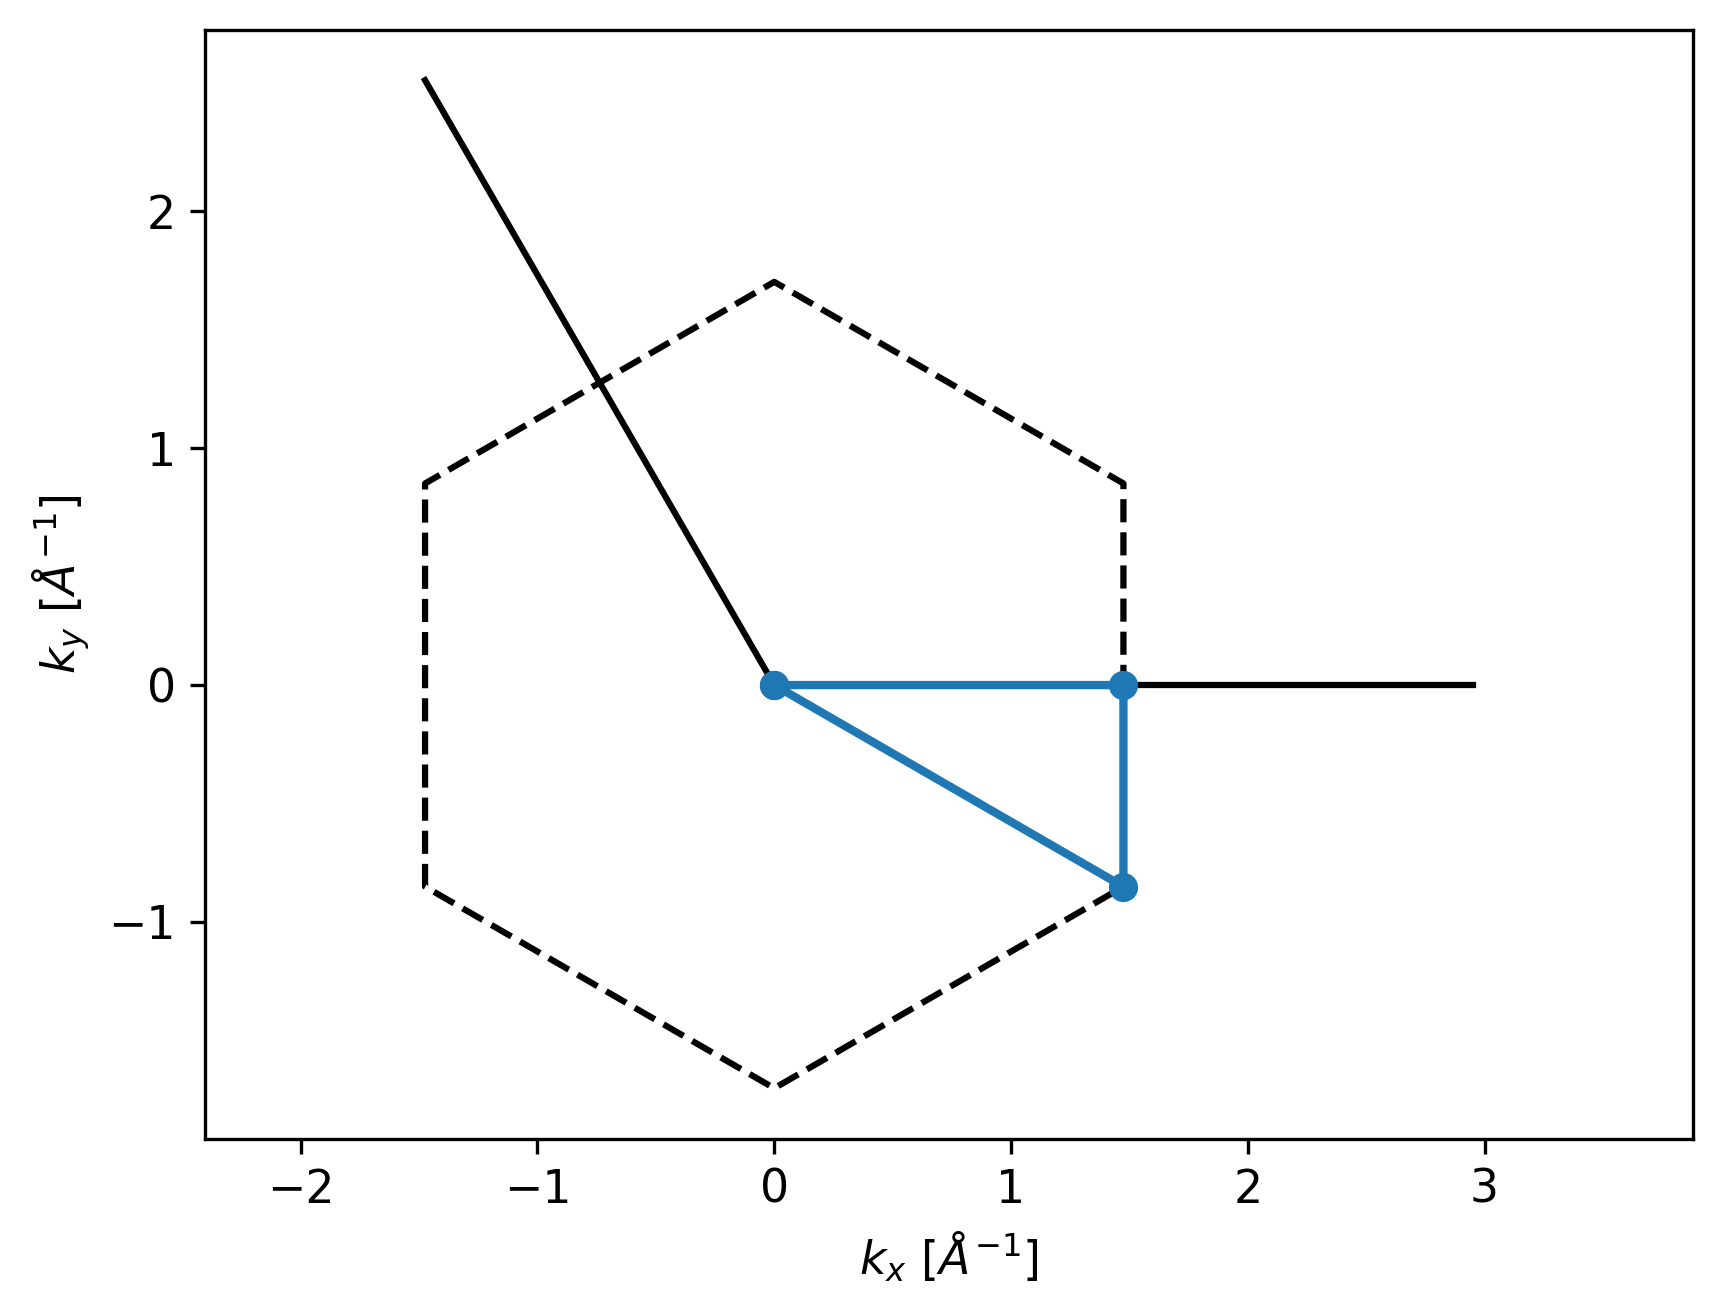

In [141]:
_kpoints=g.path_GMKG
g.set_kpath(_kpoints,[100,100,100])
_kpoints=np.array(_kpoints)

vertices=np.array([g.K[0],g.Kp[0],g.K[1],g.Kp[1],g.K[2],g.Kp[2],g.K[0]])
plt.plot([0,g.G1[0]],[0,g.G1[1]],'k-')
plt.plot([0,g.G2[0]],[0,g.G2[1]],'k-')
plt.plot(vertices[:,0],vertices[:,1],'k--')
plt.plot(_kpoints[:,0],_kpoints[:,1],'o-',lw=2)
plt.axis('equal')
plt.xlabel(r'$k_x$ [$Å^{-1}$]')
plt.ylabel(r'$k_y$ [$Å^{-1}$]')
plt.show()

In [142]:
Efermi=0.0#0.3504
g.calc_bands(nbands=4,Ef=Efermi)

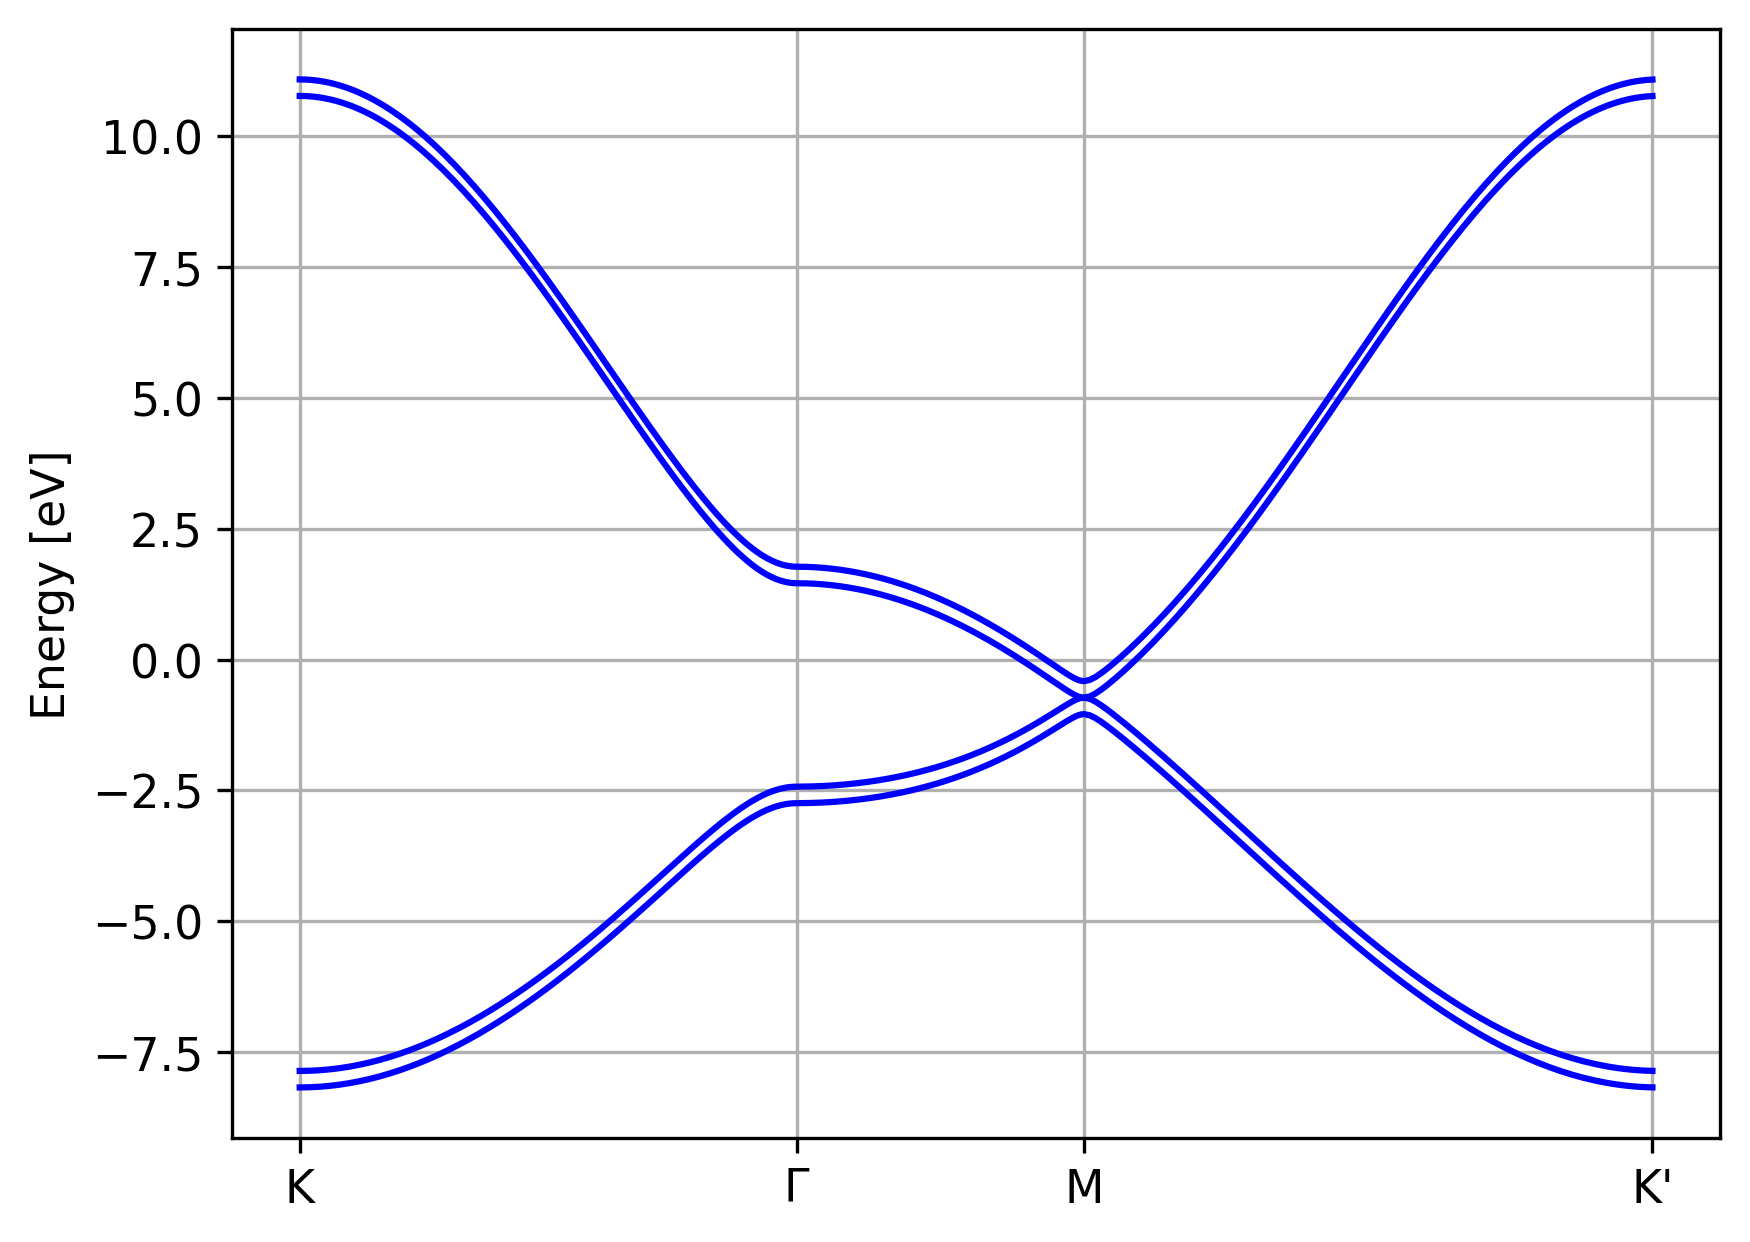

In [143]:
plt.plot(g.ell,g.bands+Efermi,'b')
plt.xticks(g.ell[g.kticks],['K','$\Gamma$','M',"K'"])
plt.grid(True)#,axis='x')
plt.ylabel('Energy [eV]')
plt.show()

In [189]:
def t_intra(x1,y1,x2,y2,max_distance=0.6): #graphene intralayer hoppings
    a=2.46 #Angstrom
    x=x2-x1
    y=y2-y1
    r=np.sqrt(x**2+y**2)/a
    t=np.zeros_like(r)
    t[(0.3  < r) * (r < 0.8 )] = -2.8922   #1st neighbors = 0.5774
    t[(0.8  < r) * (r < 1.1 )] =  0.2425  #2nd neighbors = 1.0
    t[(1.1  < r) * (r < 1.3 )] = -0.2656  #3rd neighbors = 1.1547
    t[(1.3  < r) * (r < 1.6 )] =  0.0235  #4th neighbors = 1.5275
    t[(1.6  < r) * (r < 1.8 )] =  0.0524  #5th neighbors = 1.7321
    t[(1.8  < r) * (r < 2.05)] = -0.0209  #6th neighbors = 2.0
    t[(2.05 < r) * (r < 2.1 )] = -0.0148  #7th neighbors = 2.0817
    t[(2.1  < r) * (r < 2.35)] = -0.0211  #8th neighbors = 2.3094
    t[(r > max_distance)] = 0.0
    return t

In [304]:
def AB_graphene(max_distance,Efermi):
    g=TwistedBilayerGraphene(0,1)
    g.calc_hops(max_distance,t_intra=t_intra)
    g.set_hamiltonian(interlayer=1.0,V=0.0)
    _kpoints=g.path_GMKG
    g.set_kpath(_kpoints,[100,100,100])
    _kpoints=np.array(_kpoints)
    g.calc_bands(nbands=4,Ef=Efermi)
    return g

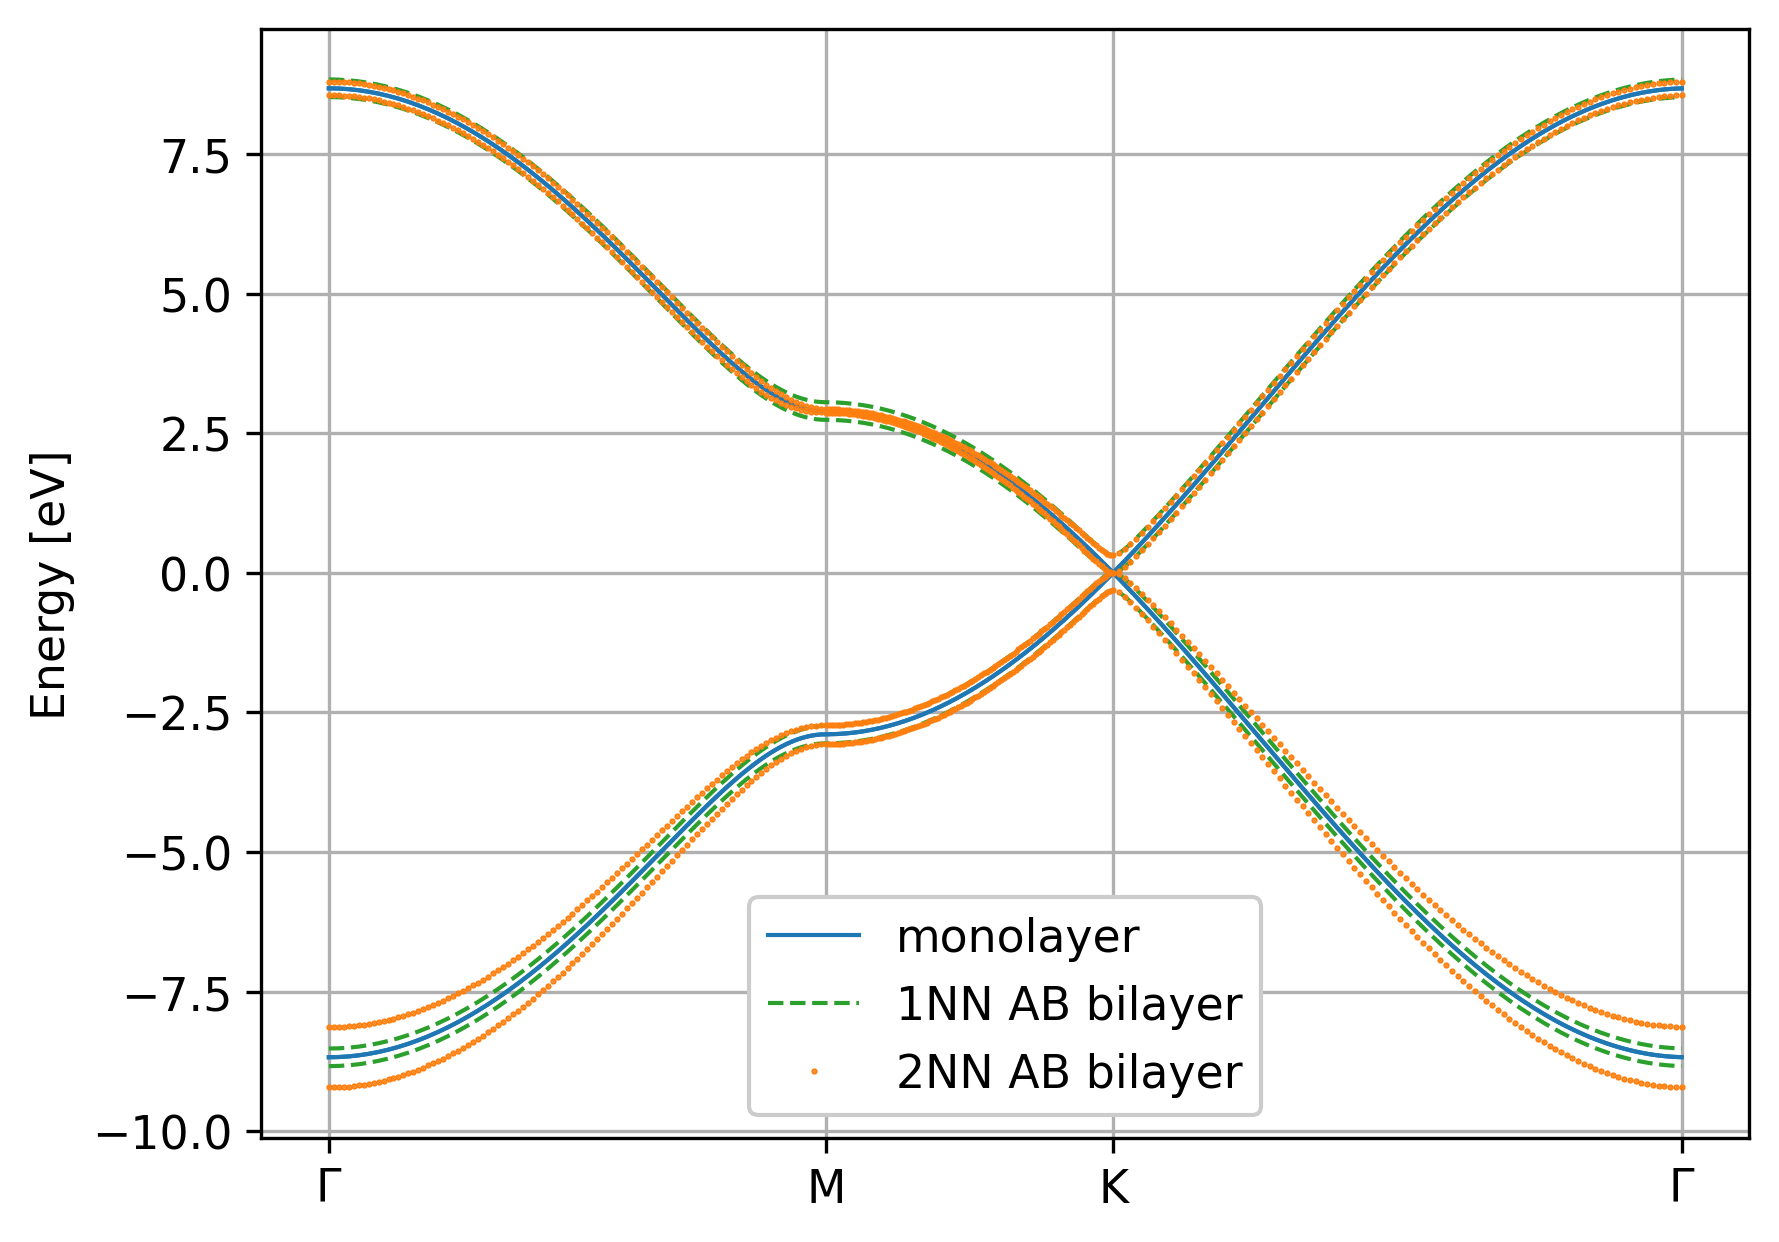

In [317]:
Efermi=0.0
g=AB_graphene(1.48,Efermi)
plt.plot(g.ell,g.bands+Efermi,color='tab:blue',lw=1)

Efermi=0.0
g=AB_graphene(3.36,Efermi)
plt.plot(g.ell,g.bands+Efermi,'--',color='tab:green',lw=1.0)

Efermi=0.0
g=AB_graphene(3.65,Efermi)
plt.plot(g.ell,g.bands+Efermi,'.',color='tab:orange',ms=1)

plt.xticks(g.ell[g.kticks],['$\Gamma$','M',"K",'$\Gamma$'])
plt.grid(True)#,axis='x')
plt.ylabel('Energy [eV]')
plt.legend(['monolayer']+3*['__nolegend__']+['1NN AB bilayer']+3*['__nolegend__']+['2NN AB bilayer'],framealpha=1.0,loc='lower center')
plt.show()

In [319]:
def AB_graphene(max_distance,Efermi):
    g=TwistedBilayerGraphene(0,1)
    g.calc_hops(max_distance,t_intra=t_intra)
    g.set_hamiltonian(interlayer=1.0,V=0.0)
    _kpoints=g.path_GMKG
    g.set_kpath(_kpoints,[100,300,300])
    _kpoints=np.array(_kpoints)
    g.calc_bands(nbands=4,Ef=Efermi)
    return g

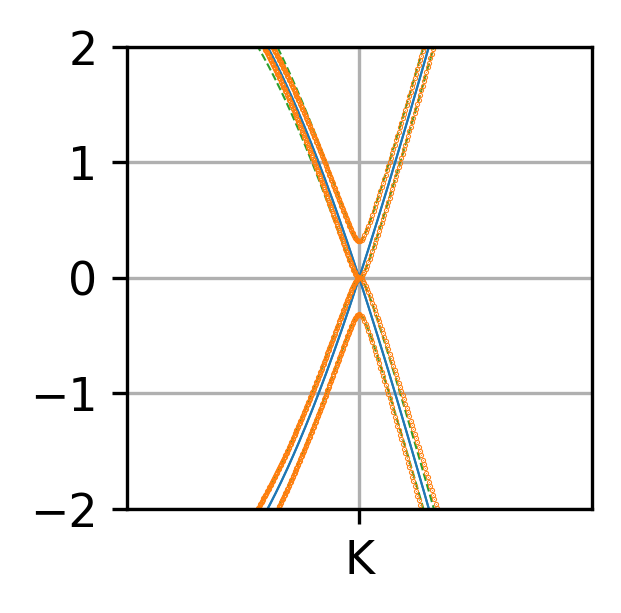

In [302]:
plt.figure(figsize=(2,2))

Efermi=0.0
g=AB_graphene(1.48,Efermi)
plt.plot(g.ell,g.bands+Efermi,color='tab:blue',lw=0.5)

Efermi=0.0
g=AB_graphene(3.36,Efermi)
plt.plot(g.ell,g.bands+Efermi,'--',color='tab:green',lw=0.5)

Efermi=0.0
g=AB_graphene(3.65,Efermi)
plt.plot(g.ell,g.bands+Efermi,'.',color='tab:orange',ms=0.5)

plt.xticks([g.ell[g.kticks[2]]],["K"])
plt.grid(True)#,axis='x')
plt.ylim((-2.0,2.0))
radius=1.0
plt.xlim((g.ell[g.kticks[2]]-radius,g.ell[g.kticks[2]]+radius))
# plt.ylabel('Energy [eV]')
plt.show()

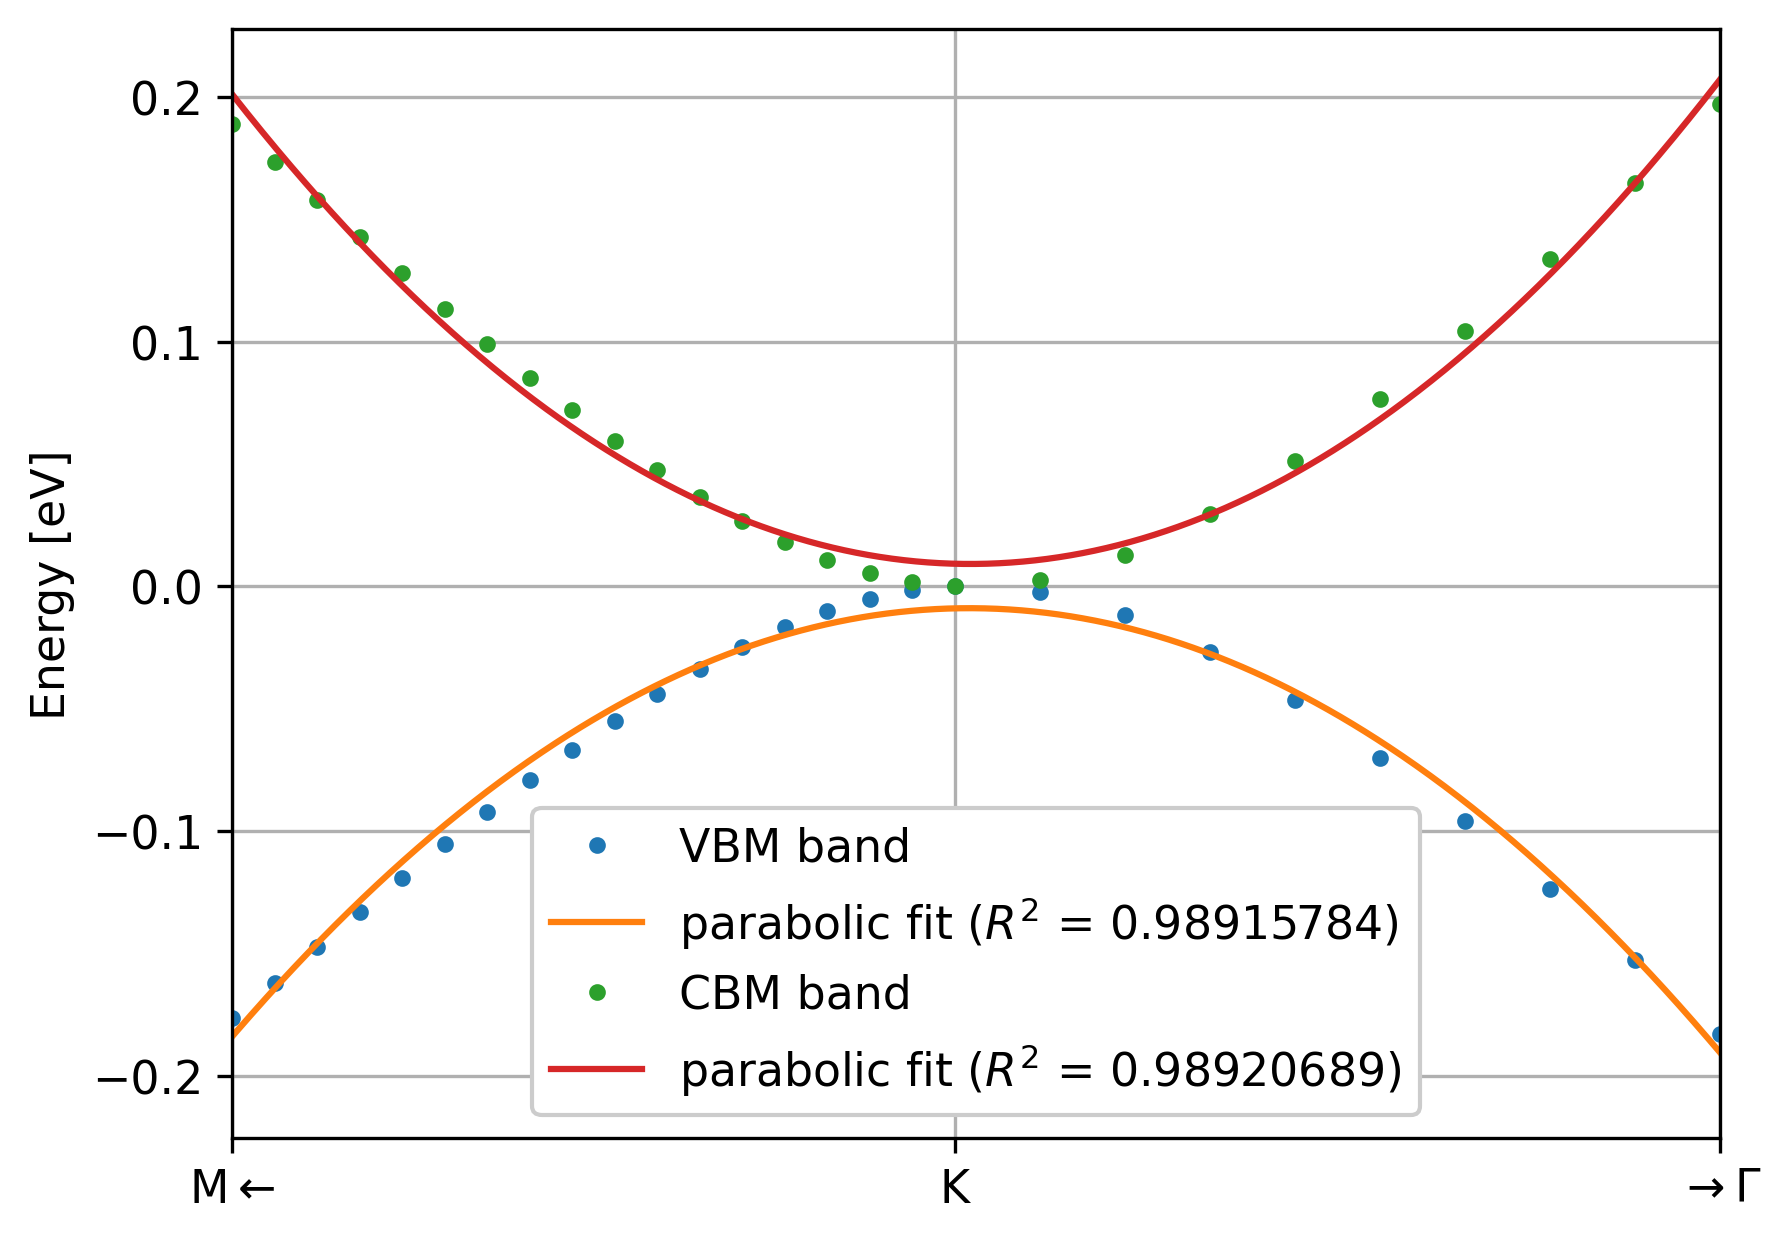

In [321]:
g=AB_graphene(3.65,Efermi)

band=g.bands[:,1]
mask=np.abs(band)<0.2
x=g.ell[mask]
y=band[mask]
p,residuals, rank, singular_values, rcond=np.polyfit(x,y,deg=2,full=True)
a,b,c=p
R21=(np.corrcoef(y,a*x**2+b*x+c)[0,1])**2
xx=np.linspace(x[0],x[-1],1000)
plt.plot(x,y,'.')
plt.plot(xx,a*xx**2+b*xx+c)

band=g.bands[:,2]
mask=np.abs(band)<0.2
x=g.ell[mask]
y=band[mask]
p,residuals, rank, singular_values, rcond=np.polyfit(x,y,deg=2,full=True)
a,b,c=p
R22=(np.corrcoef(y,a*x**2+b*x+c)[0,1])**2
xx=np.linspace(x[0],x[-1],1000)
plt.plot(x,y,'.')
plt.plot(xx,a*xx**2+b*xx+c)

plt.xticks([x[0],g.ell[g.kticks[2]],x[-1]],[r'M$\leftarrow$',"K",r'$\rightarrow\Gamma$'])
plt.xlim((x[0],x[-1]))
plt.ylabel('Energy [eV]')
plt.grid(True)
plt.legend(['VBM band',f'parabolic fit ($R^2$ = {R21:.8f})', 'CBM band', f'parabolic fit ($R^2$ = {R22:.8f})'],framealpha=1.0)
plt.show()

In [194]:
def t_intra(x1,y1,x2,y2,max_distance=0.6): #graphene intralayer hoppings
    a=2.46 #Angstrom
    x=x2-x1
    y=y2-y1
    r=np.sqrt(x**2+y**2)/a
    t=np.zeros_like(r)
    t[(0.3  < r) * (r < 0.8 )] = -2.8922   #1st neighbors = 0.5774
    t[(0.8  < r) * (r < 1.1 )] =  0.2425  #2nd neighbors = 1.0
    t[(1.1  < r) * (r < 1.3 )] = -0.2656  #3rd neighbors = 1.1547
    t[(1.3  < r) * (r < 1.6 )] =  0.0235  #4th neighbors = 1.5275
    t[(1.6  < r) * (r < 1.8 )] =  0.0524  #5th neighbors = 1.7321
    t[(1.8  < r) * (r < 2.05)] = -0.0209  #6th neighbors = 2.0
    t[(2.05 < r) * (r < 2.1 )] = -0.0148  #7th neighbors = 2.0817
    t[(2.1  < r) * (r < 2.35)] = -0.0211  #8th neighbors = 2.3094
    t[(r > max_distance)] = 0.0
    return t

In [199]:
def AA_graphene(max_distance,Efermi):
    g=TwistedBilayerGraphene(1,0)
    g.calc_hops(max_distance,t_intra=t_intra)
    g.set_hamiltonian(interlayer=1.0,V=0.0)
    _kpoints=g.path_GMKG
    g.set_kpath(_kpoints,[100,50,100])
    _kpoints=np.array(_kpoints)
    g.calc_bands(nbands=4,Ef=Efermi)
    return g

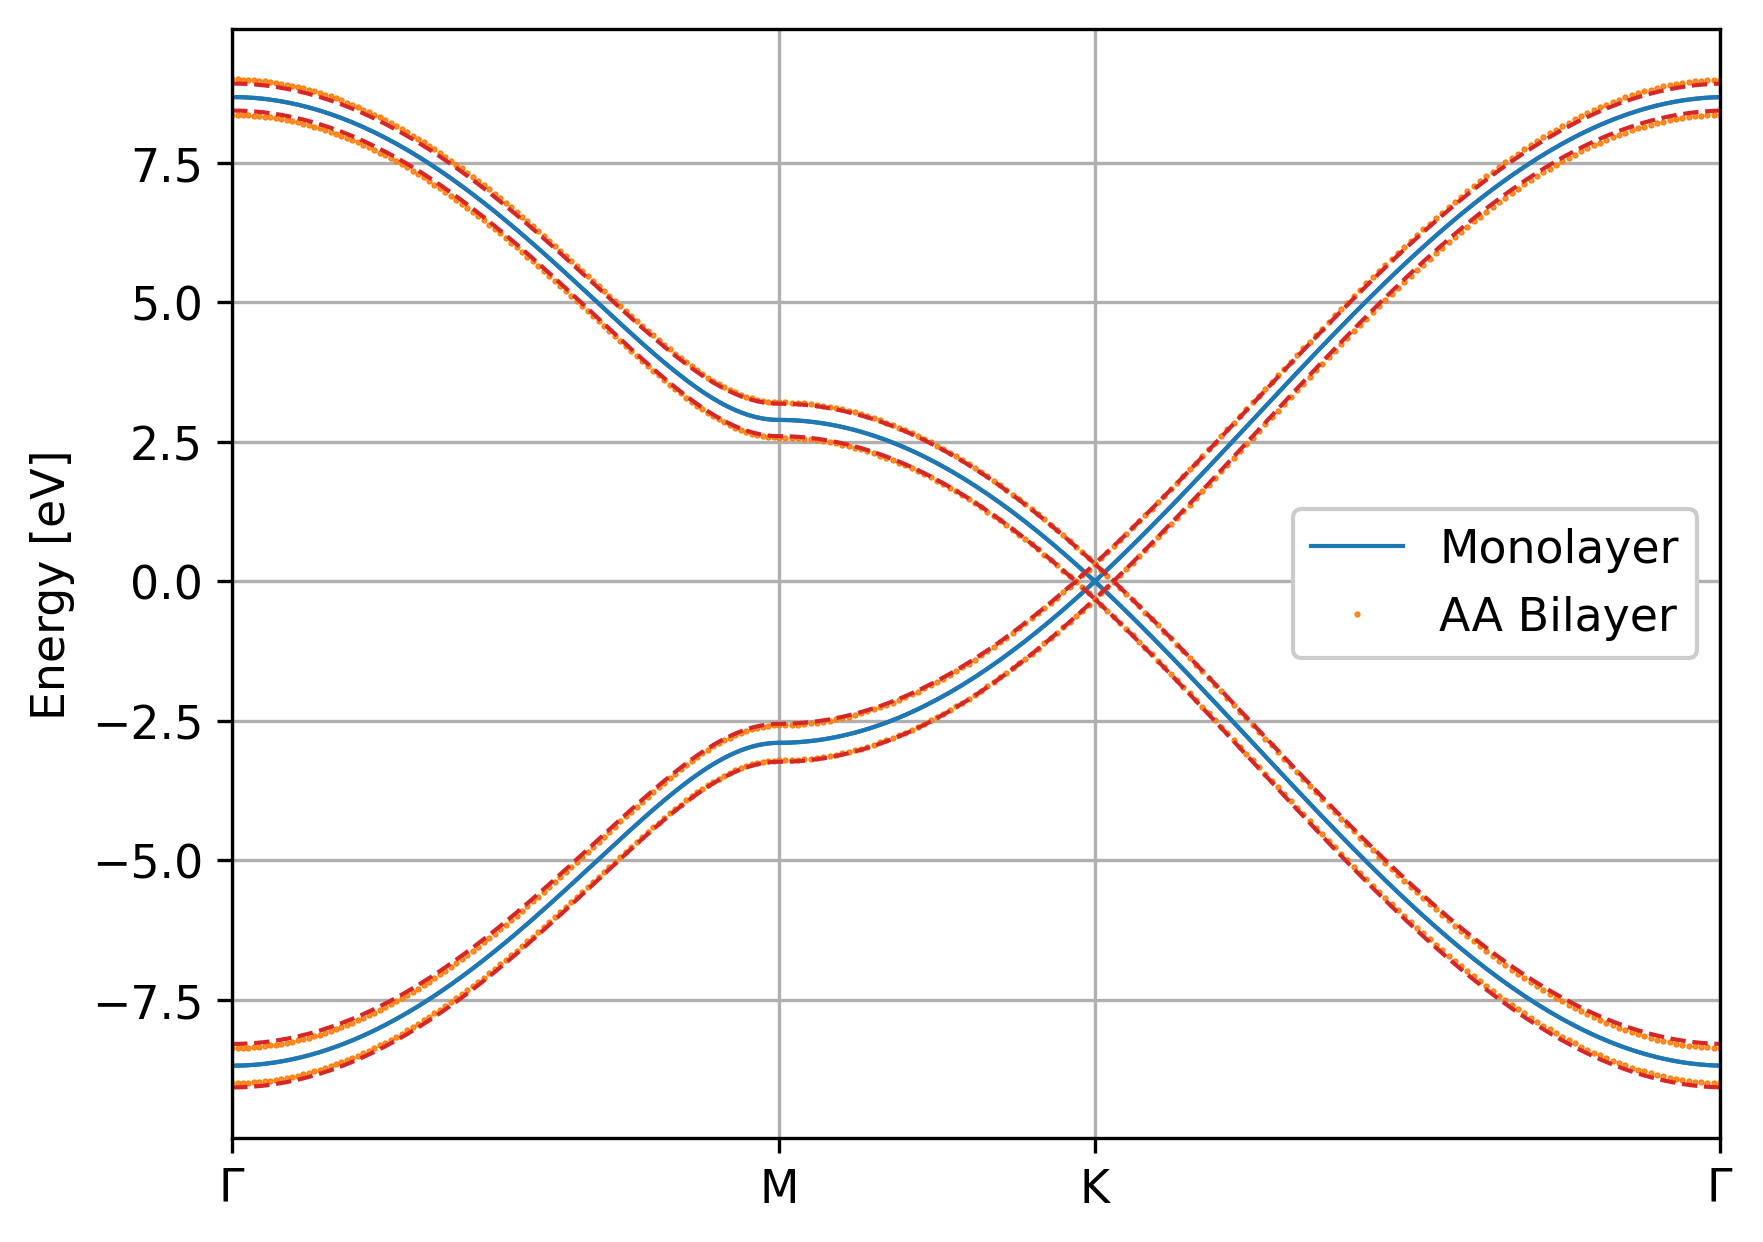

In [310]:
Efermi=0.0
g=AA_graphene(1.48,Efermi)
plt.plot(g.ell,g.bands+Efermi,color='tab:blue',lw=1)

Efermi=0.0
g=AA_graphene(3.36,Efermi)
plt.plot(g.ell,g.bands+Efermi,'.',color='tab:orange',ms=1)

Efermi=0.0
g=AA_graphene(4.0,Efermi)
plt.plot(g.ell,g.bands+Efermi,'--',color='tab:red',lw=1.0)

plt.xticks(g.ell[g.kticks],['$\Gamma$','M',"K",'$\Gamma$'])
plt.grid(True)#,axis='x')
plt.ylabel('Energy [eV]')
plt.legend(['Monolayer']+3*['__nolegend__']+['AA Bilayer'],framealpha=1.0)
plt.xlim((g.ell[0],g.ell[-1]))
plt.show()

In [49]:
def t_intra(x1,y1,x2,y2): #graphene intralayer hoppings
    a=2.46 #Angstrom
    x=x2-x1
    y=y2-y1
    r=np.sqrt(x**2+y**2)/a
    t=np.zeros_like(r)
    t[(0.3  < r) * (r < 0.8 )] = -2.8922   #1st neighbors = 0.5774
#     t[(0.8  < r) * (r < 1.1 )] =  0.2425  #2nd neighbors = 1.0
#     t[(1.1  < r) * (r < 1.3 )] = -0.2656  #3rd neighbors = 1.1547
#     t[(1.3  < r) * (r < 1.6 )] =  0.0235  #4th neighbors = 1.5275
#     t[(1.6  < r) * (r < 1.8 )] =  0.0524  #5th neighbors = 1.7321
#     t[(1.8  < r) * (r < 2.05)] = -0.0209  #6th neighbors = 2.0
#     t[(2.05 < r) * (r < 2.1 )] = -0.0148  #7th neighbors = 2.0817
#     t[(2.1  < r) * (r < 2.35)] = -0.0211  #8th neighbors = 2.3094
    return t

In [59]:
@interact_manual(max_distance=(1.0,8.0,0.01))
def plot(max_distance=1.46):

    g=TwistedBilayerGraphene(1,1)
    g.set_kpath(g.path_GMKG,[100,100,100])
    g.calc_hops(max_distance,t_intra=t_intra)
    g.set_hamiltonian(0.0,0.0)
    nbands=10
    g.calc_bands(nbands,0.0)
    g.bands0=g.bands
    g.set_hamiltonian(1.0,0.0)
    g.calc_bands(nbands,0.0)
    g.bands1=g.bands

    plt.plot(g.ell,g.bands0,'.',color='tab:blue',ms=1)
    plt.plot(g.ell,g.bands1,'.',color='tab:orange',ms=1)

    plt.xticks(g.ell[g.kticks],['$\Gamma$','M',"K",'$\Gamma$'])
    plt.grid(True)#,axis='x')
    plt.ylabel('Energy [eV]')
    # plt.legend(['Monolayer']+3*['__nolegend__']+['AA Bilayer'],framealpha=1.0)
    plt.xlim((g.ell[0],g.ell[-1]))
    plt.show()

interactive(children=(FloatSlider(value=1.46, description='max_distance', max=8.0, min=1.0, step=0.01), Button…

In [42]:
2.46/3**0.5

1.4202816622064793

In [58]:
np.sqrt(3.35**2+5.0**2)

6.018513105410671